In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from sklearn.model_selection import train_test_split

Total: 108
Train: 86
Test: 22


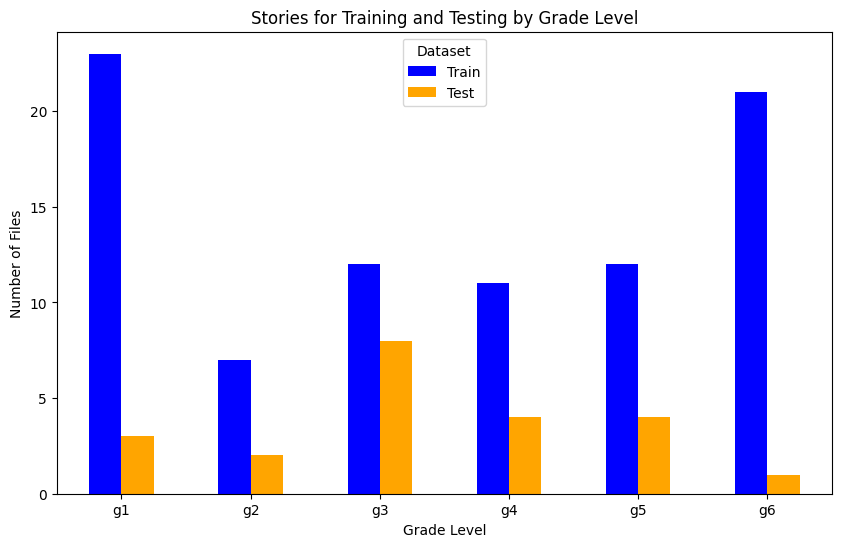

In [5]:
base_dir = "../txt/utf"
test_size=0.2
random_seed=42

all_files = []
for root, _, files in os.walk(base_dir):
    grade = os.path.basename(root)
    for file in files:
        if file.endswith(".txt"):
            all_files.append((os.path.join(root, file), grade))

random.seed(random_seed)
random.shuffle(all_files)
train_files, test_files = train_test_split(all_files, test_size=test_size, random_state=random_seed)

train_grades = [grade for _, grade in train_files]
test_grades = [grade for _, grade in test_files]

train_grade_counts = pd.Series(train_grades).value_counts().sort_index()
test_grade_counts = pd.Series(test_grades).value_counts().sort_index()

grade_data = pd.DataFrame({
    'Train': train_grade_counts,
    'Test': test_grade_counts
}).fillna(0)  # Fill NaN with 0 for missing grade levels

print(f"Total: {len(all_files)}")
print(f"Train: {len(train_files)}")
print(f"Test: {len(test_files)}")


grade_data.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange'])
plt.title('Stories for Training and Testing by Grade Level')
plt.xlabel('Grade Level')
plt.ylabel('Number of Files')
plt.xticks(rotation=0)
plt.legend(title='Dataset')

plt.show()


In [6]:
df = pd.read_csv('../tables/dataset.csv')
df = df[df['text_num'] != 18]
df = df.drop(columns=['stride_index', 'n_gram', 'word_num'], axis=1)
df["grade_level"] = df["grade_level"].astype("category")

print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   text_num grade_level  stride_len  noun_tr  verb_tr  type_tr  lex_density  \
0        44           4           1      0.0      0.0      1.0          0.0   
1        44           4           1      1.0      0.0      1.0          1.0   
2        44           4           1      0.0      1.0      1.0          1.0   
3        44           4           1      0.0      0.0      1.0          0.0   
4        44           4           1      0.0      0.0      1.0          1.0   

   lex_foreign   sent_len  word_len  syll_num  poly_num  
0          0.0  14.066667       5.0       1.0         0  
1          0.0  14.066667       4.0       1.0         0  
2          0.0  14.066667       3.0       1.0         0  
3          0.0  14.066667       5.0       1.0         0  
4          0.0  14.066667       6.0       2.0         1  


In [7]:
# Feature data type
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 201176 entries, 0 to 254975
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   text_num     201176 non-null  int64   
 1   grade_level  201176 non-null  category
 2   stride_len   201176 non-null  int64   
 3   noun_tr      201176 non-null  float64 
 4   verb_tr      201176 non-null  float64 
 5   type_tr      201176 non-null  float64 
 6   lex_density  201176 non-null  float64 
 7   lex_foreign  201176 non-null  float64 
 8   sent_len     201176 non-null  float64 
 9   word_len     201176 non-null  float64 
 10  syll_num     201176 non-null  float64 
 11  poly_num     201176 non-null  int64   
dtypes: category(1), float64(8), int64(3)
memory usage: 18.6 MB
None


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
text_num       0
grade_level    0
stride_len     0
noun_tr        0
verb_tr        0
type_tr        0
lex_density    0
lex_foreign    0
sent_len       0
word_len       0
syll_num       0
poly_num       0
dtype: int64


In [9]:
# Summary statistics of numerical columns
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
            text_num     stride_len        noun_tr        verb_tr  \
count  201176.000000  201176.000000  201176.000000  201176.000000   
mean       38.320003      23.281057       0.259728       0.131138   
std        22.909314      40.125375       0.294009       0.224504   
min         4.000000       1.000000       0.000000       0.000000   
25%        17.000000       1.000000       0.000000       0.000000   
50%        34.000000       2.000000       0.230000       0.000000   
75%        52.000000       3.000000       0.333300       0.160000   
max       104.000000     100.000000       1.000000       1.000000   

             type_tr    lex_density    lex_foreign       sent_len  \
count  201176.000000  201176.000000  201176.000000  201176.000000   
mean        0.923314       0.534653       0.006684      11.945414   
std         0.144843       0.316629       0.057611       2.637311   
min         0.333300       0.000000       0.000000       4.363636   
25%         

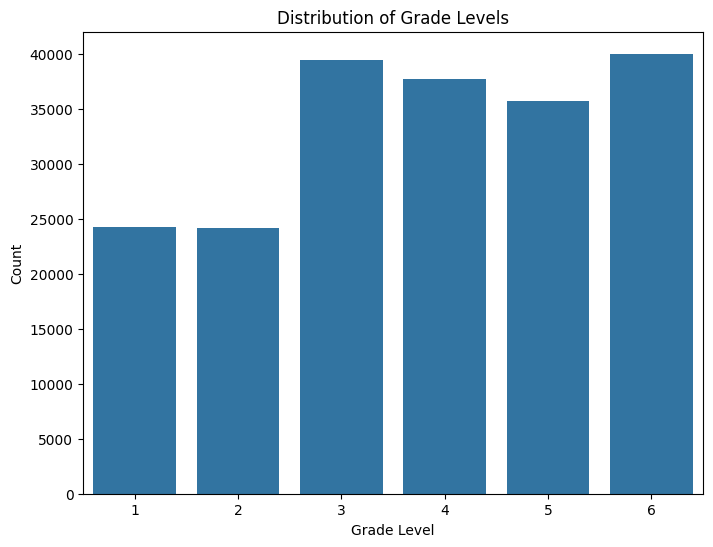

In [10]:
# Visualize the distribution of the dependent variable (grade_level)
plt.figure(figsize=(8, 6))
sns.countplot(x='grade_level', data=df)
plt.title('Distribution of Grade Levels')
plt.xlabel('Grade Level')
plt.ylabel('Count')
plt.show()

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/1221239987.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  undersampled_df = df.groupby(grade_column).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/1221239987.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  undersampled_df = df.groupby(grade_column).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)



Grade level counts after undersampling:


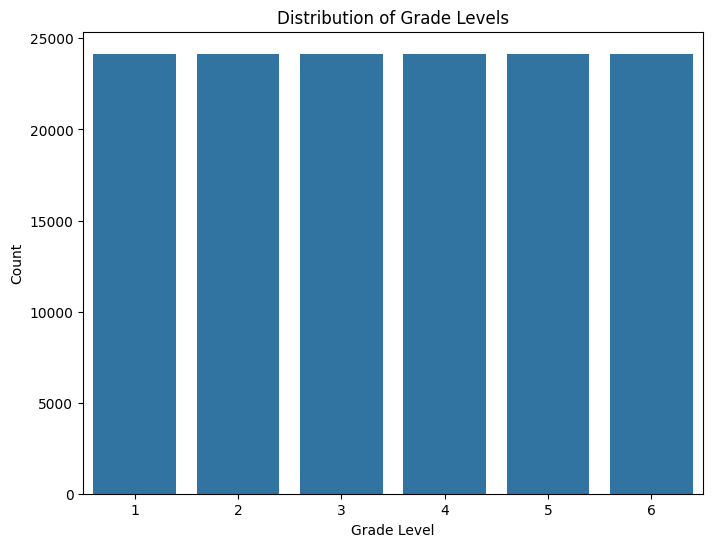

In [11]:
# Undersample the dataset to have an equal number of entries for each grade level
def undersample_dataset(df, grade_column):
    # Find the minimum count of entries across all grade levels
    min_count = df[grade_column].value_counts().min()
    # Group by grade level and sample min_count entries from each group
    undersampled_df = df.groupby(grade_column).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
    return undersampled_df

# Apply undersampling to the dataset
df_undersampled = undersample_dataset(df, 'grade_level')

# Display the count of entries per grade level after undersampling
print("\nGrade level counts after undersampling:")

# Visualize the distribution of the dependent variable (grade_level)
plt.figure(figsize=(8, 6))
sns.countplot(x='grade_level', data=df_undersampled)
plt.title('Distribution of Grade Levels')
plt.xlabel('Grade Level')
plt.ylabel('Count')
plt.show()

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/209126538.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby("grade_level")[feature_cols].mean()


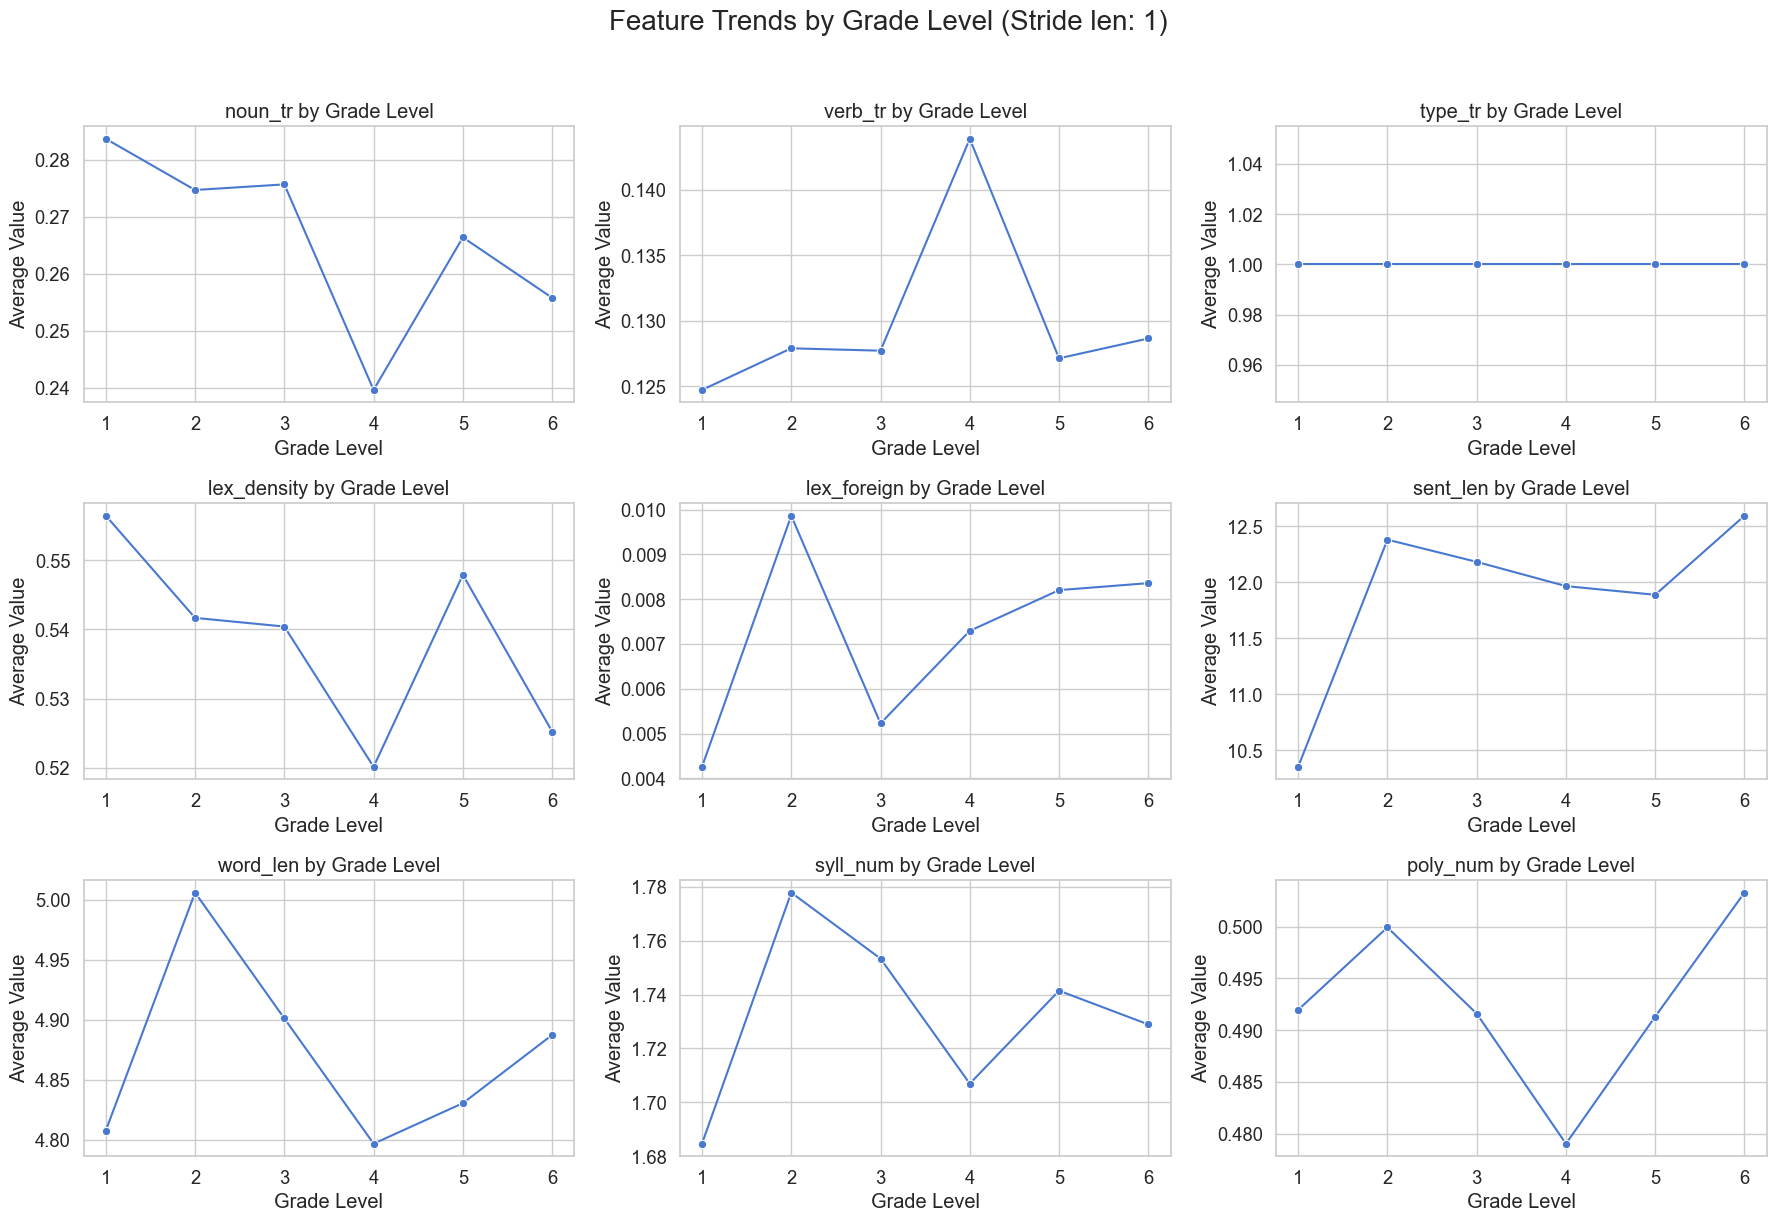

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/209126538.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby("grade_level")[feature_cols].mean()


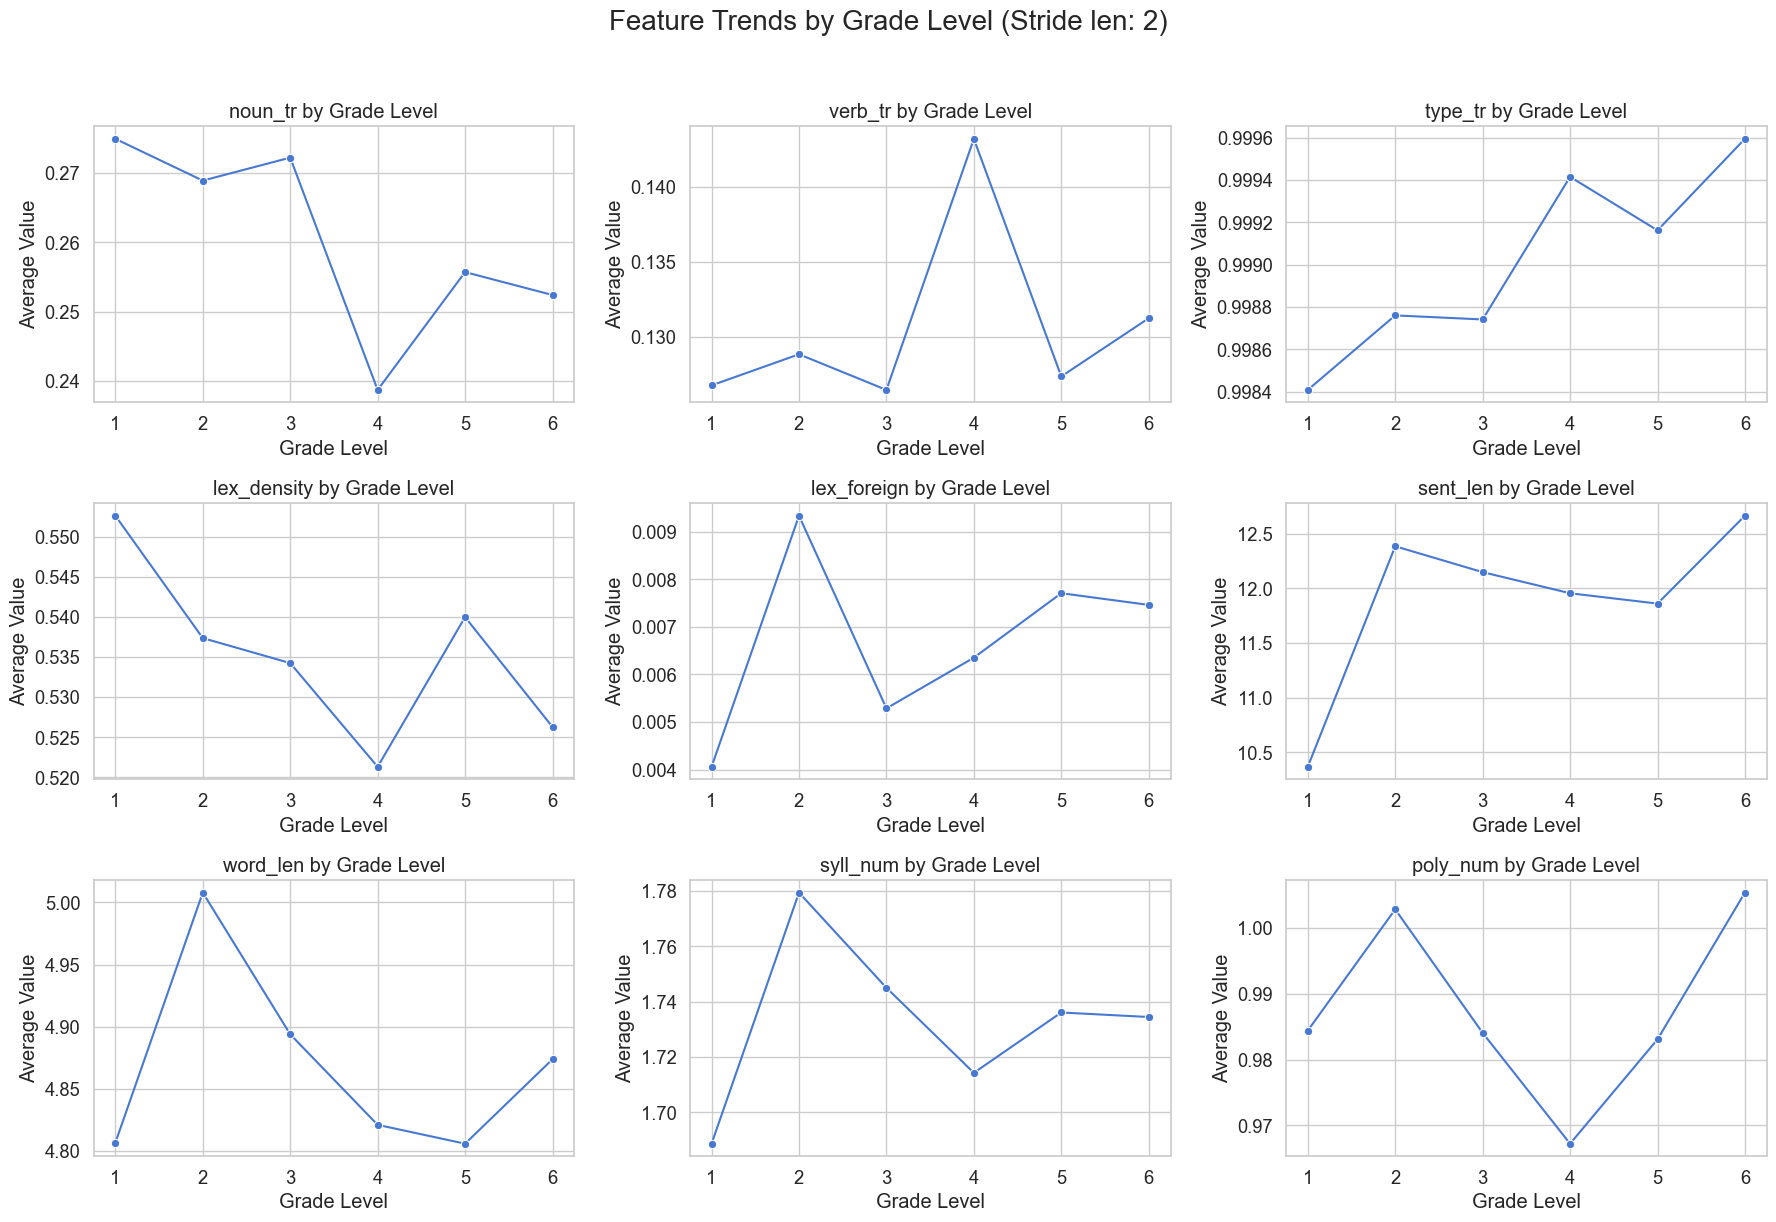

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/209126538.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby("grade_level")[feature_cols].mean()


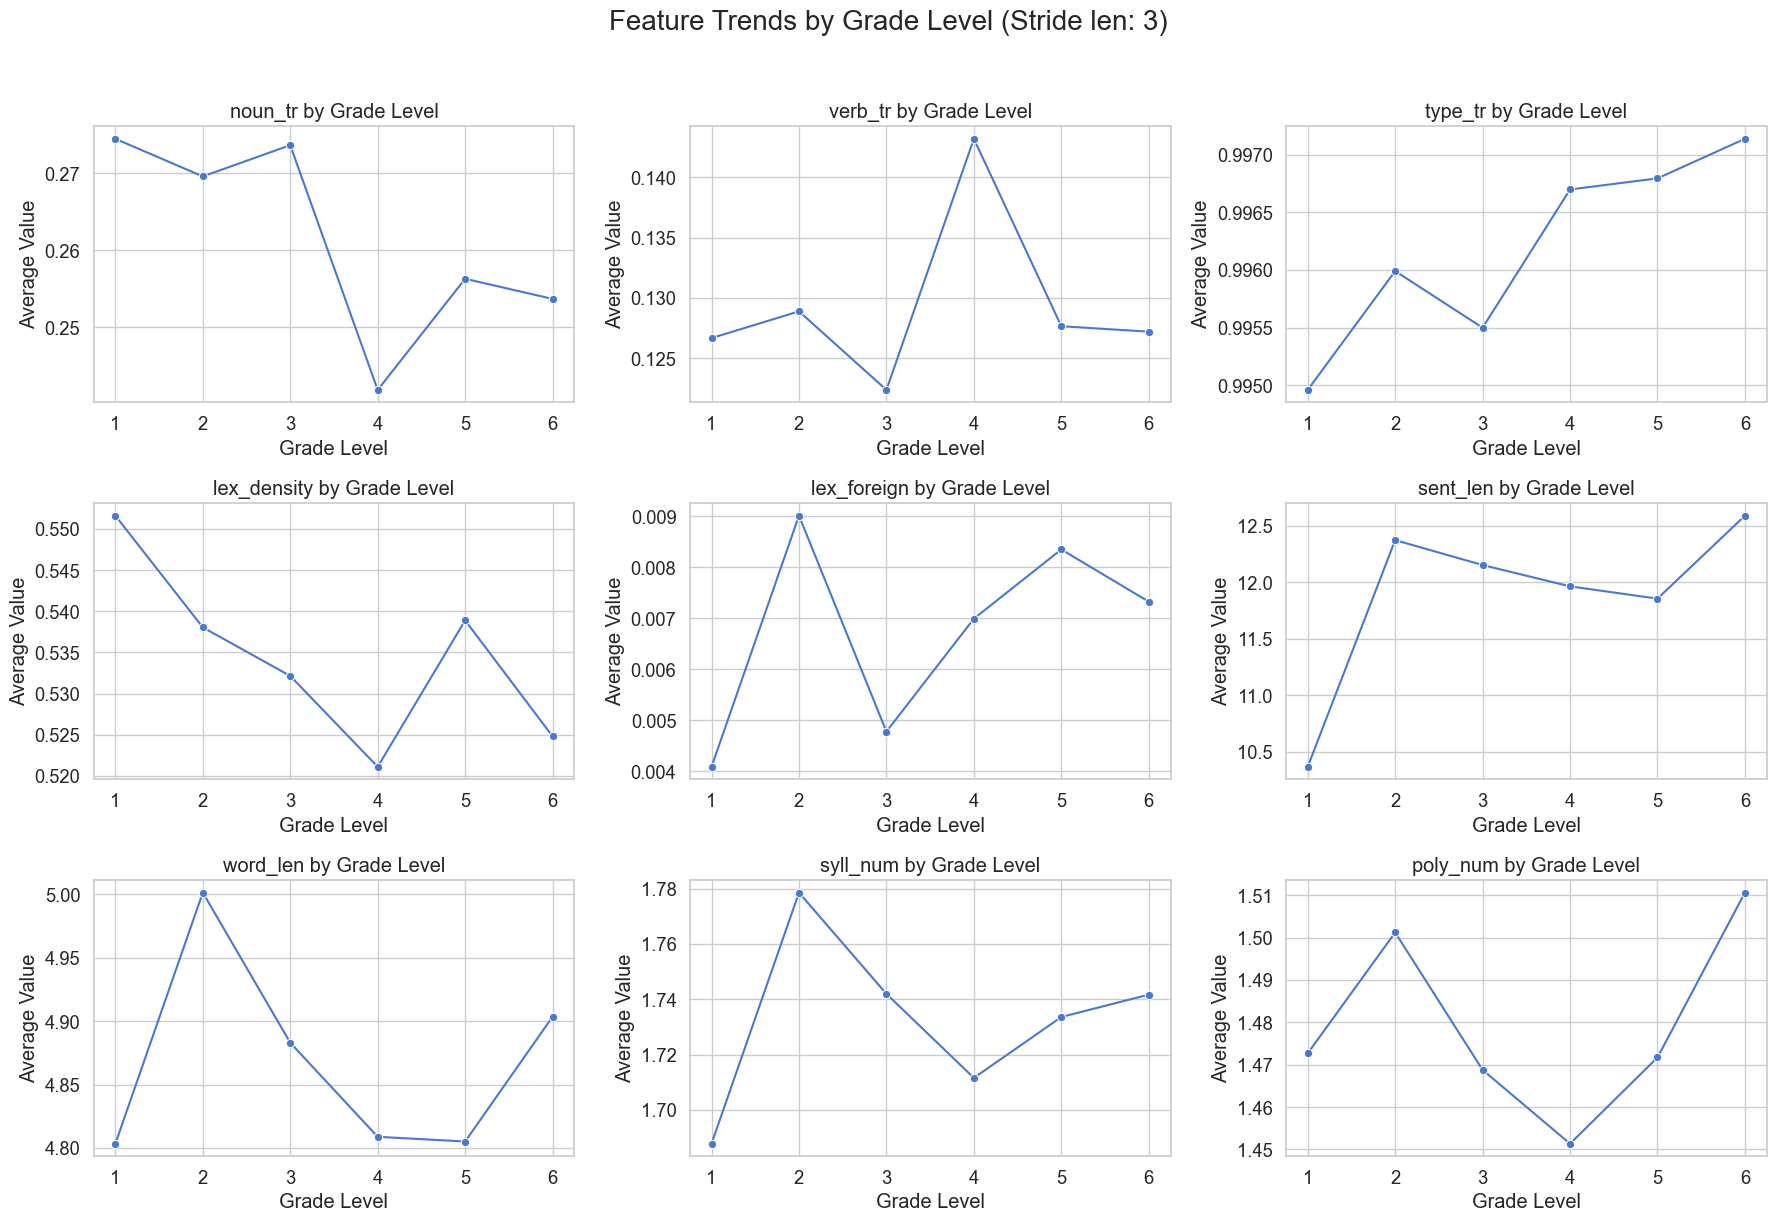

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/209126538.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby("grade_level")[feature_cols].mean()


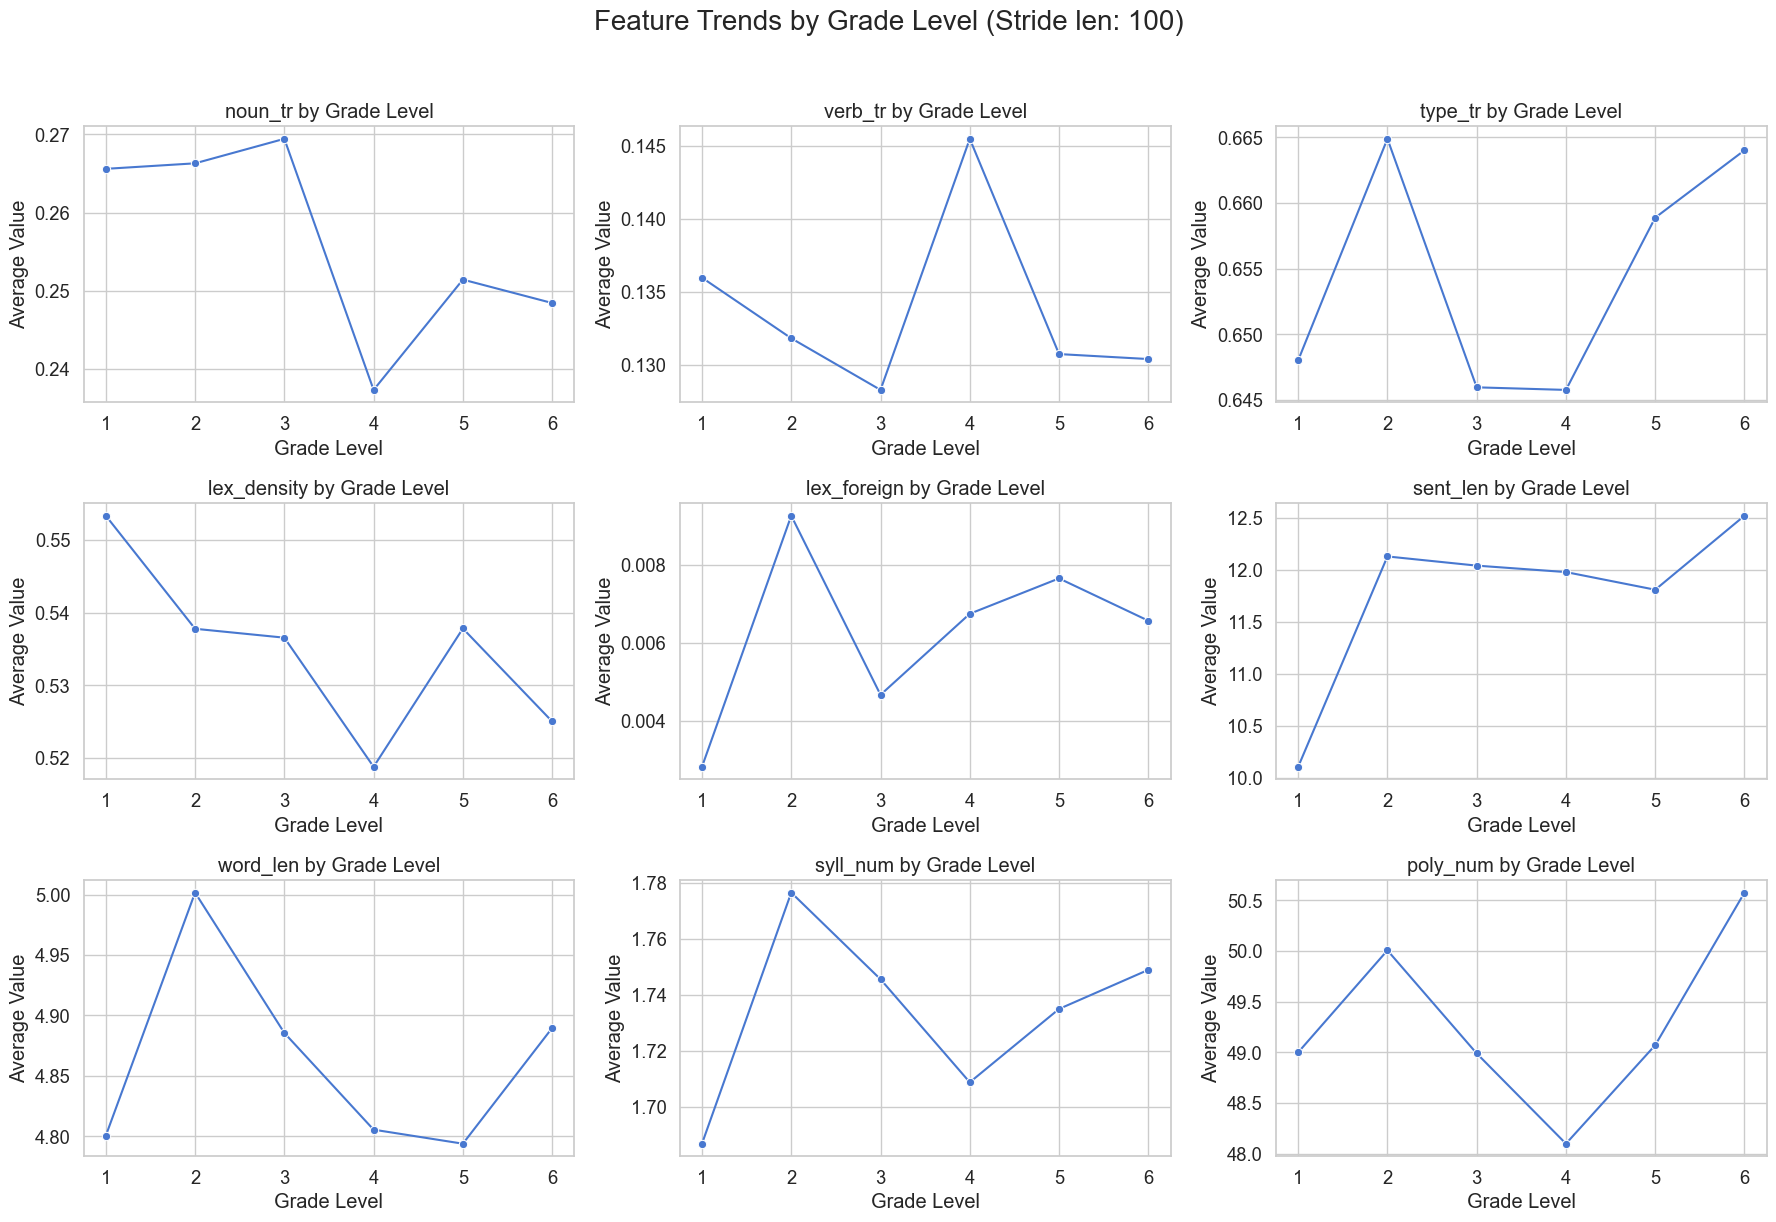

In [12]:
stride = [1, 2, 3, 100]
for s in stride:
    df_filtered = df_undersampled[df_undersampled['stride_len'] == s]
    database_name = f"Stride len: {s}"

    feature_cols = [
        "noun_tr", "verb_tr", "type_tr", "lex_density", "lex_foreign",
        "sent_len", "word_len", "syll_num", "poly_num"
    ]

    # Group by grade_level and compute average feature values
    grouped = df_filtered.groupby("grade_level")[feature_cols].mean()

    # Plot setup
    sns.set(style="whitegrid", palette="muted", font_scale=1.2)
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
    axes = axes.flatten()

    # Plot each feature
    for i, feature in enumerate(grouped.columns):
        sns.lineplot(
            x=grouped.index.astype(str),
            y=grouped[feature],
            marker='o',
            ax=axes[i]
        )
        axes[i].set_title(f"{feature} by Grade Level")
        axes[i].set_xlabel("Grade Level")
        axes[i].set_ylabel("Average Value")

    plt.suptitle(f"Feature Trends by Grade Level ({database_name})", y=1.02, fontsize=20)
    plt.tight_layout()
    plt.show()


/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/4083544489.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby("grade_level")[feature_cols].mean()


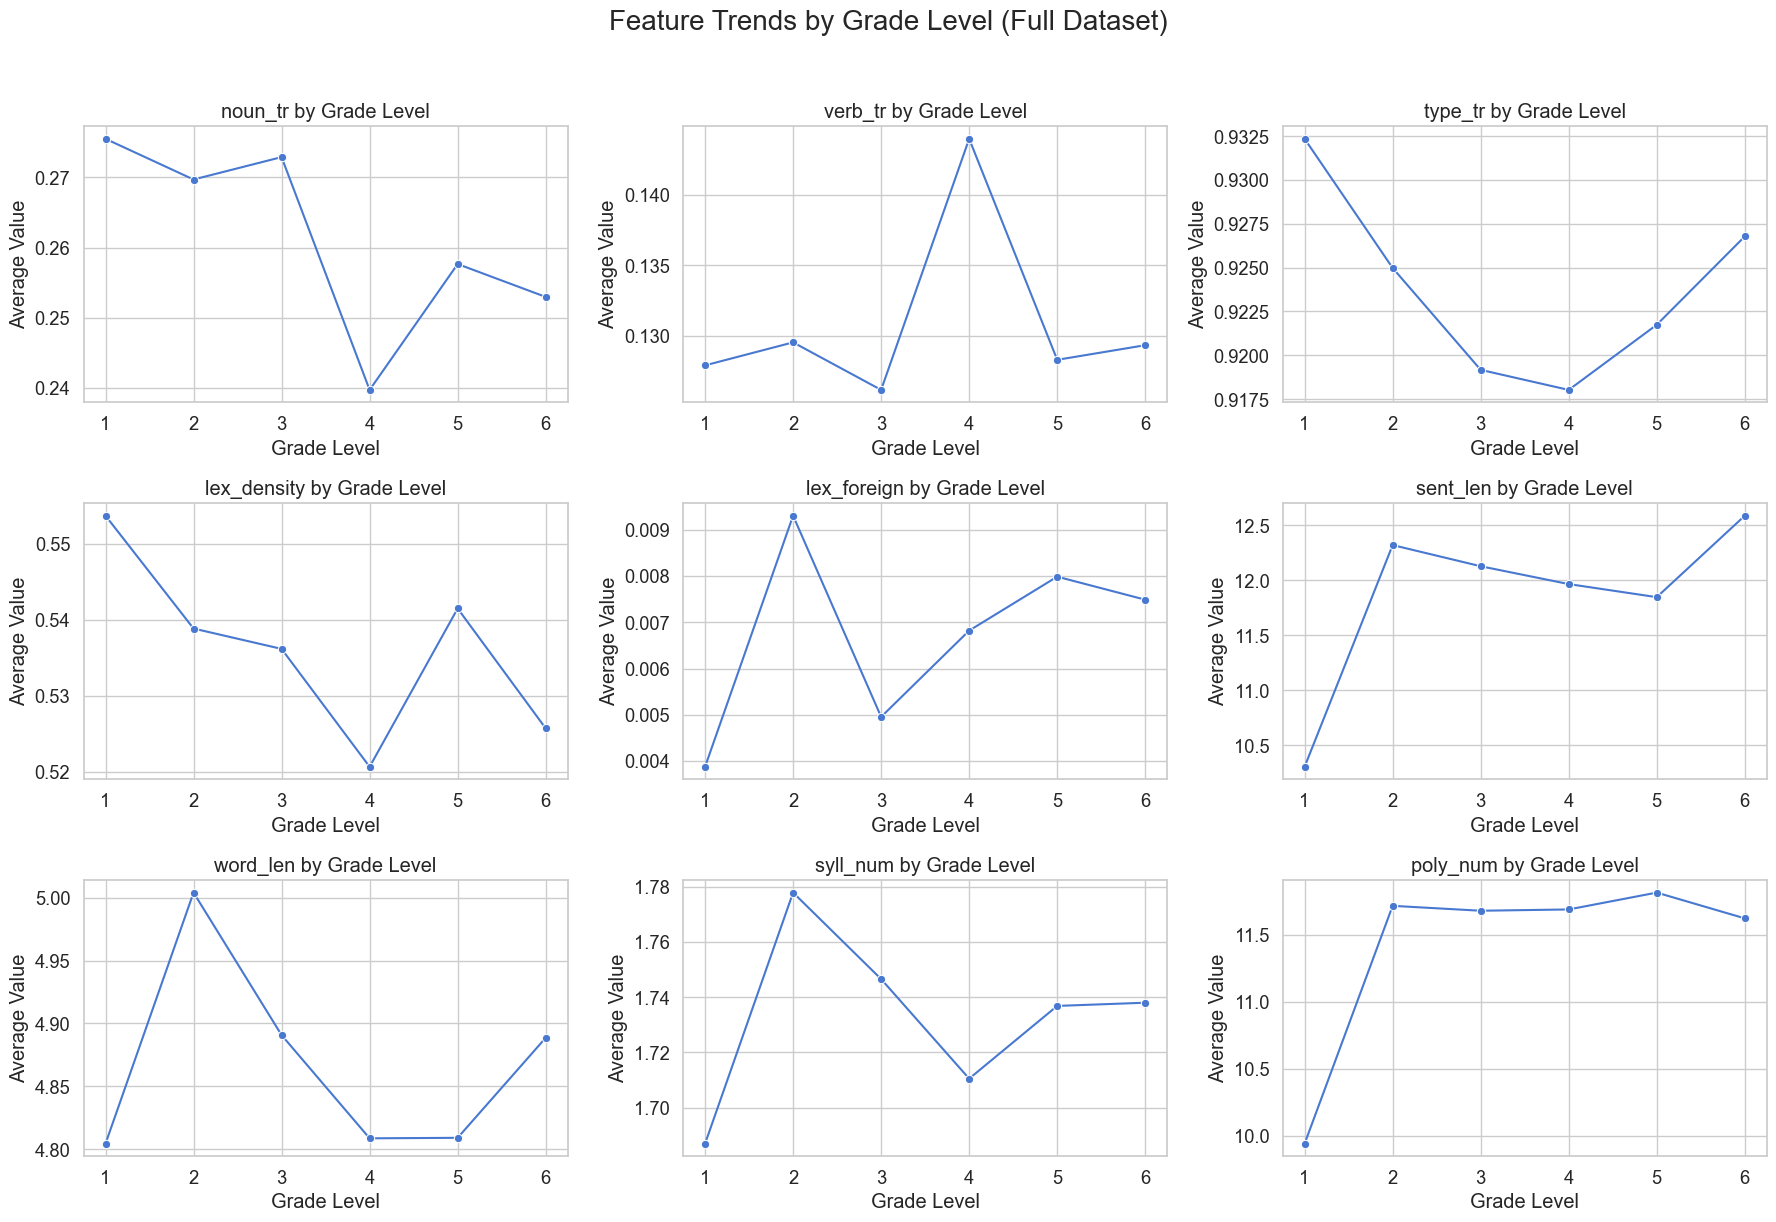

In [ ]:
# df_filtered = df_undersampled[(df_undersampled['stride_len'] > ) & (df_undersampled['stride_len'] < 100)]
# database_name = f"Sentence Fragment"

df_filtered = df[df['stride_len'] > 0]
database_name = f"Full Dataset"

feature_cols = [
    "noun_tr", "verb_tr", "type_tr", "lex_density", "lex_foreign",
    "sent_len", "word_len", "syll_num", "poly_num"
]

# Group by grade_level and compute average feature values
grouped = df_filtered.groupby("grade_level")[feature_cols].mean()

# Plot setup
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(grouped.columns):
    sns.lineplot(
        x=grouped.index.astype(str),
        y=grouped[feature],
        marker='o',
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} by Grade Level")
    axes[i].set_xlabel("Grade Level")
    axes[i].set_ylabel("Average Value")

plt.suptitle(f"Feature Trends by Grade Level ({database_name})", y=1.02, fontsize=20)
plt.tight_layout()
plt.show()


/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_mean = database.groupby("grade_level")[feature_cols].mean()
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_min = database.groupby("grade_level")[feature_cols].min()
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

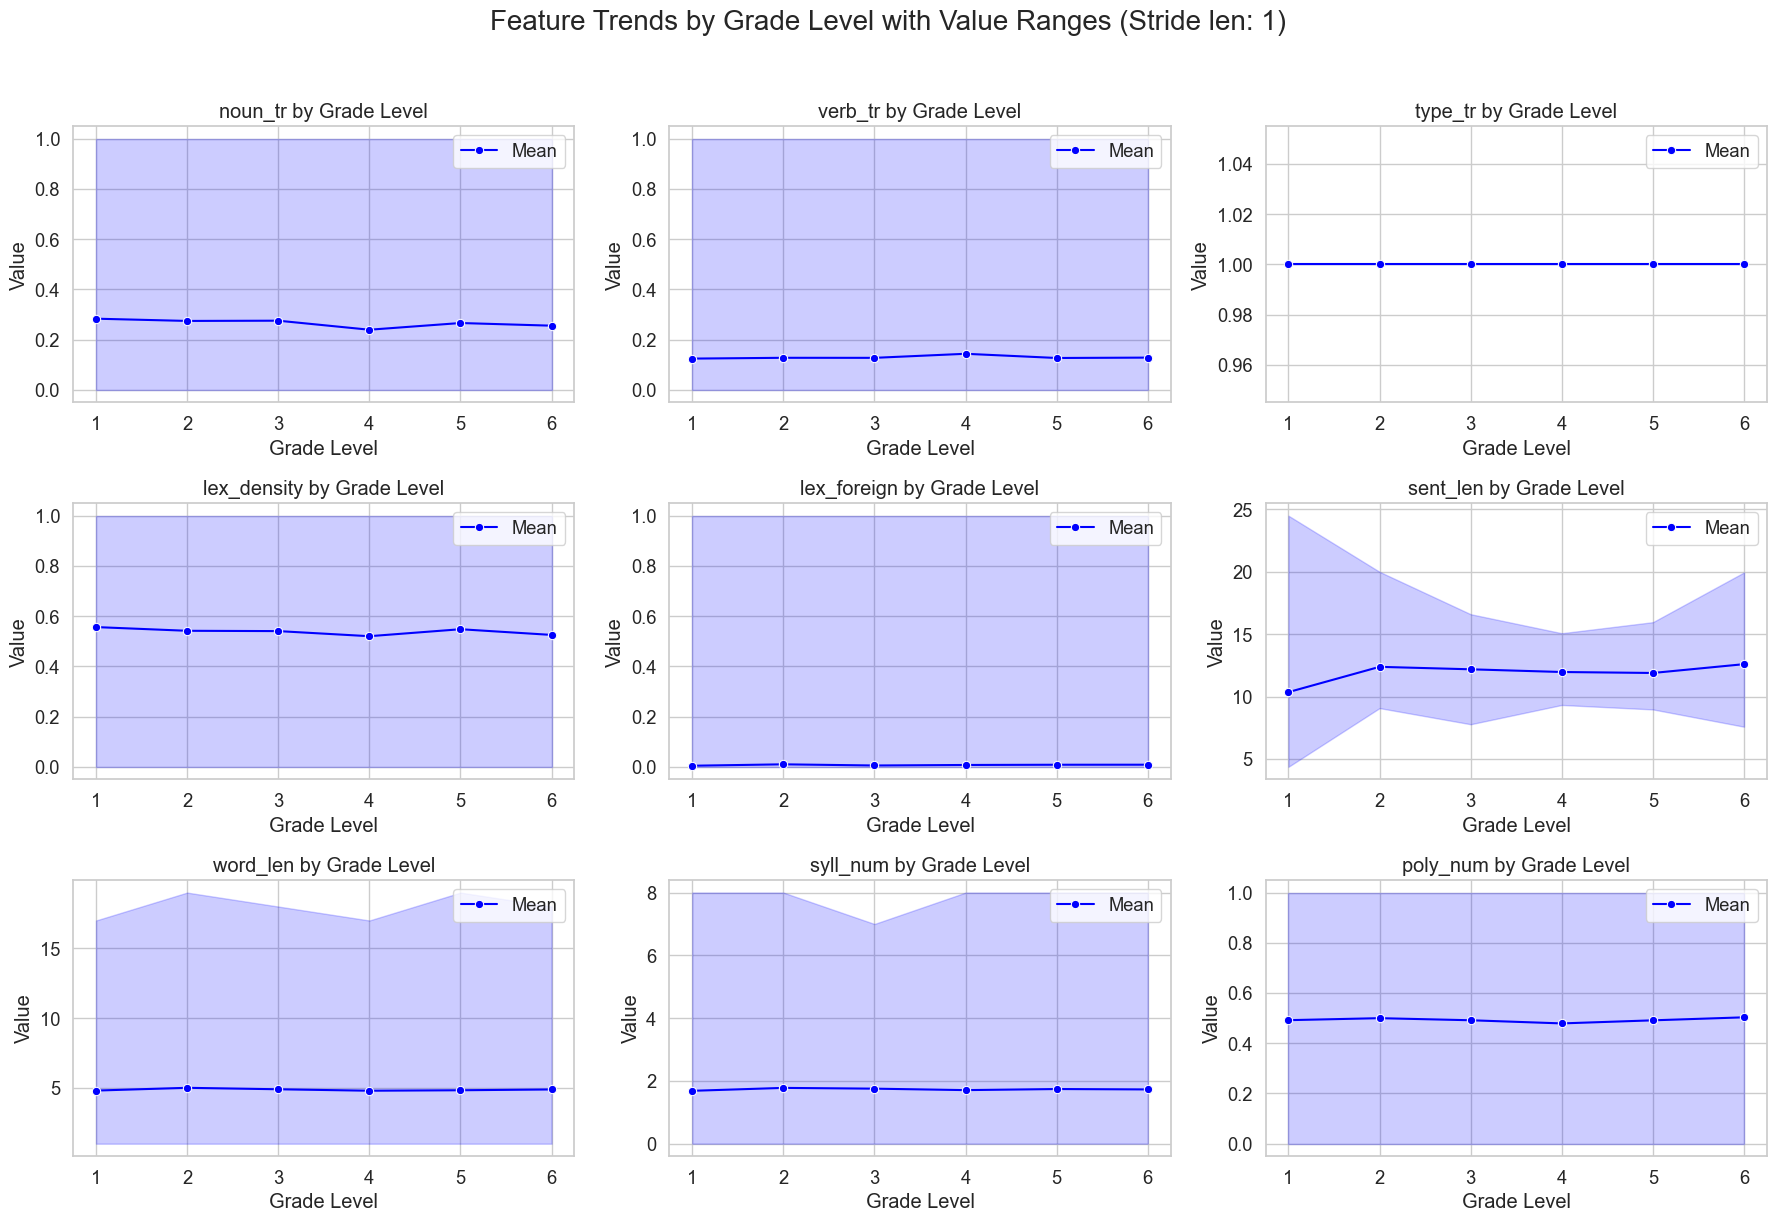

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_mean = database.groupby("grade_level")[feature_cols].mean()
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_min = database.groupby("grade_level")[feature_cols].min()
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

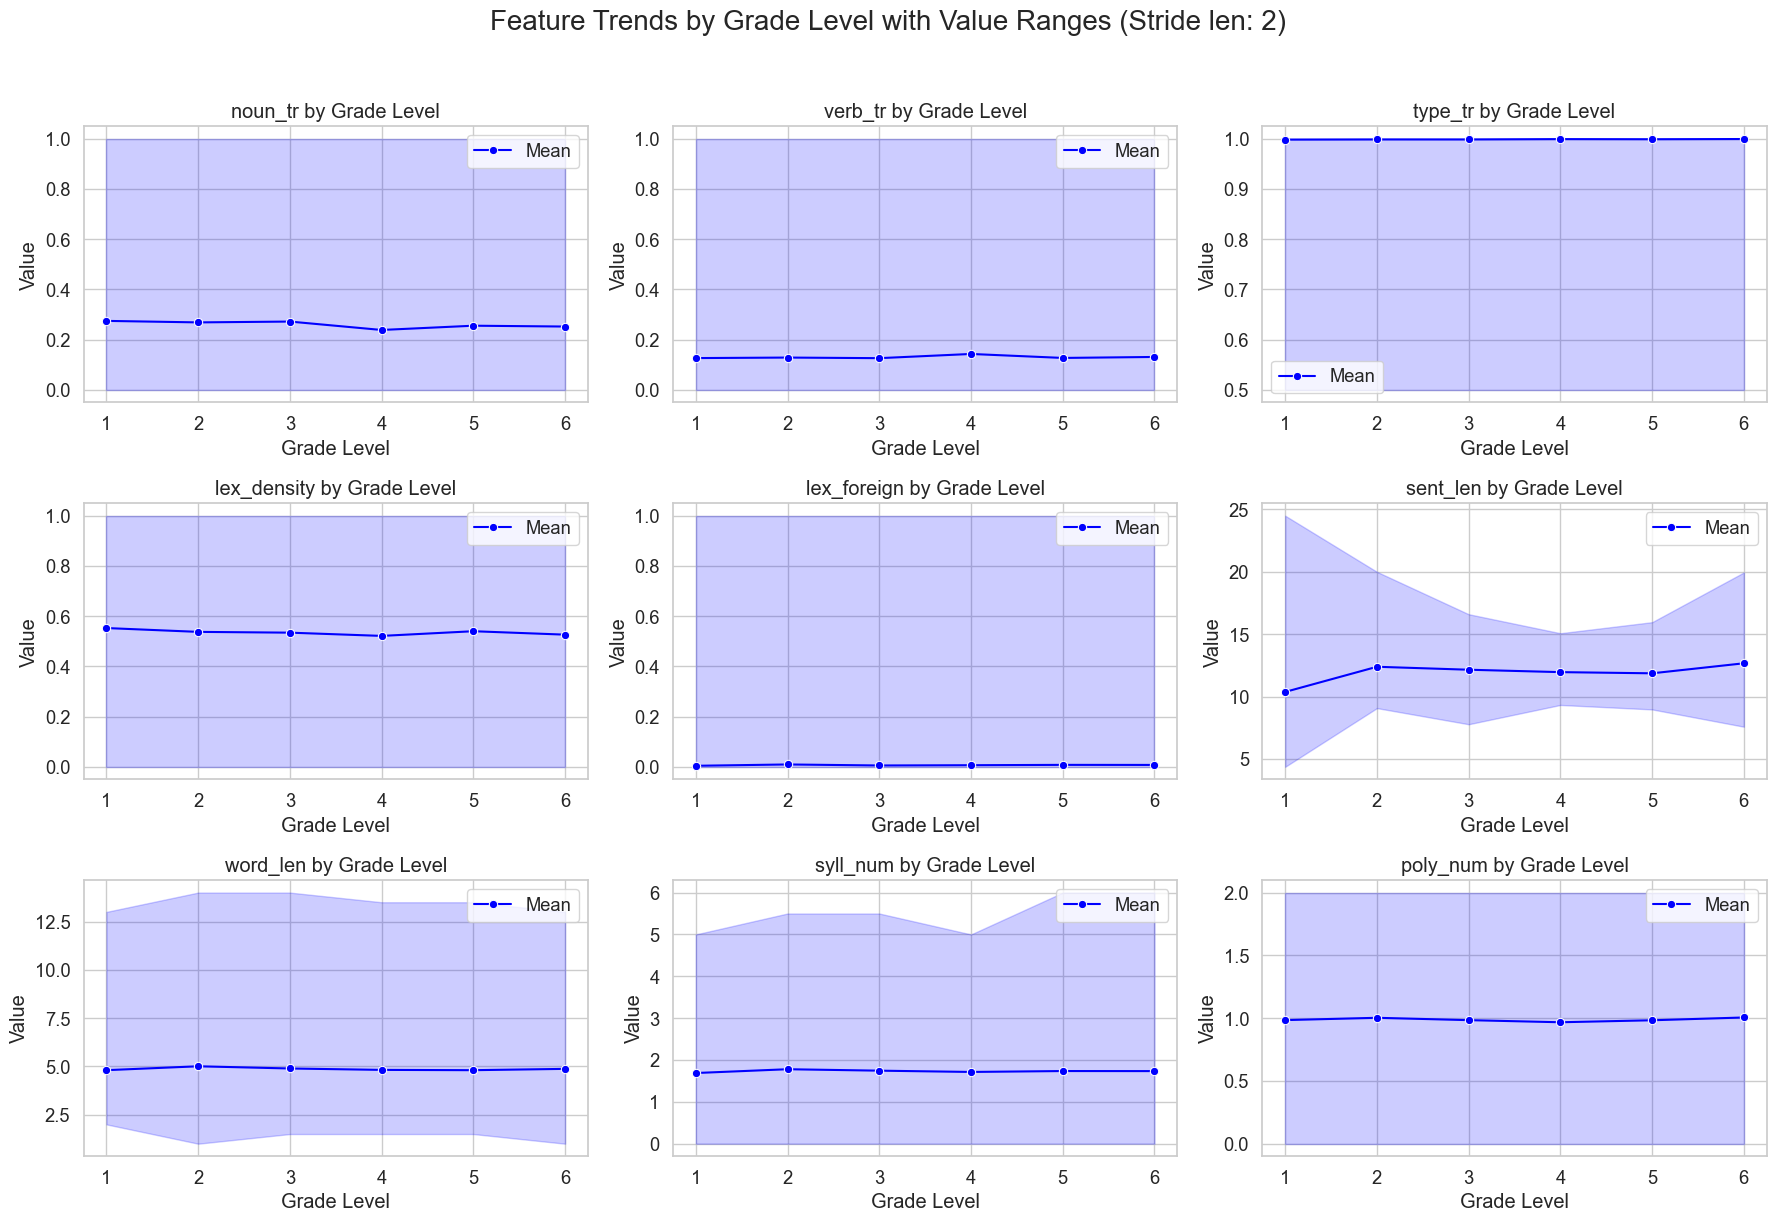

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_mean = database.groupby("grade_level")[feature_cols].mean()
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_min = database.groupby("grade_level")[feature_cols].min()
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

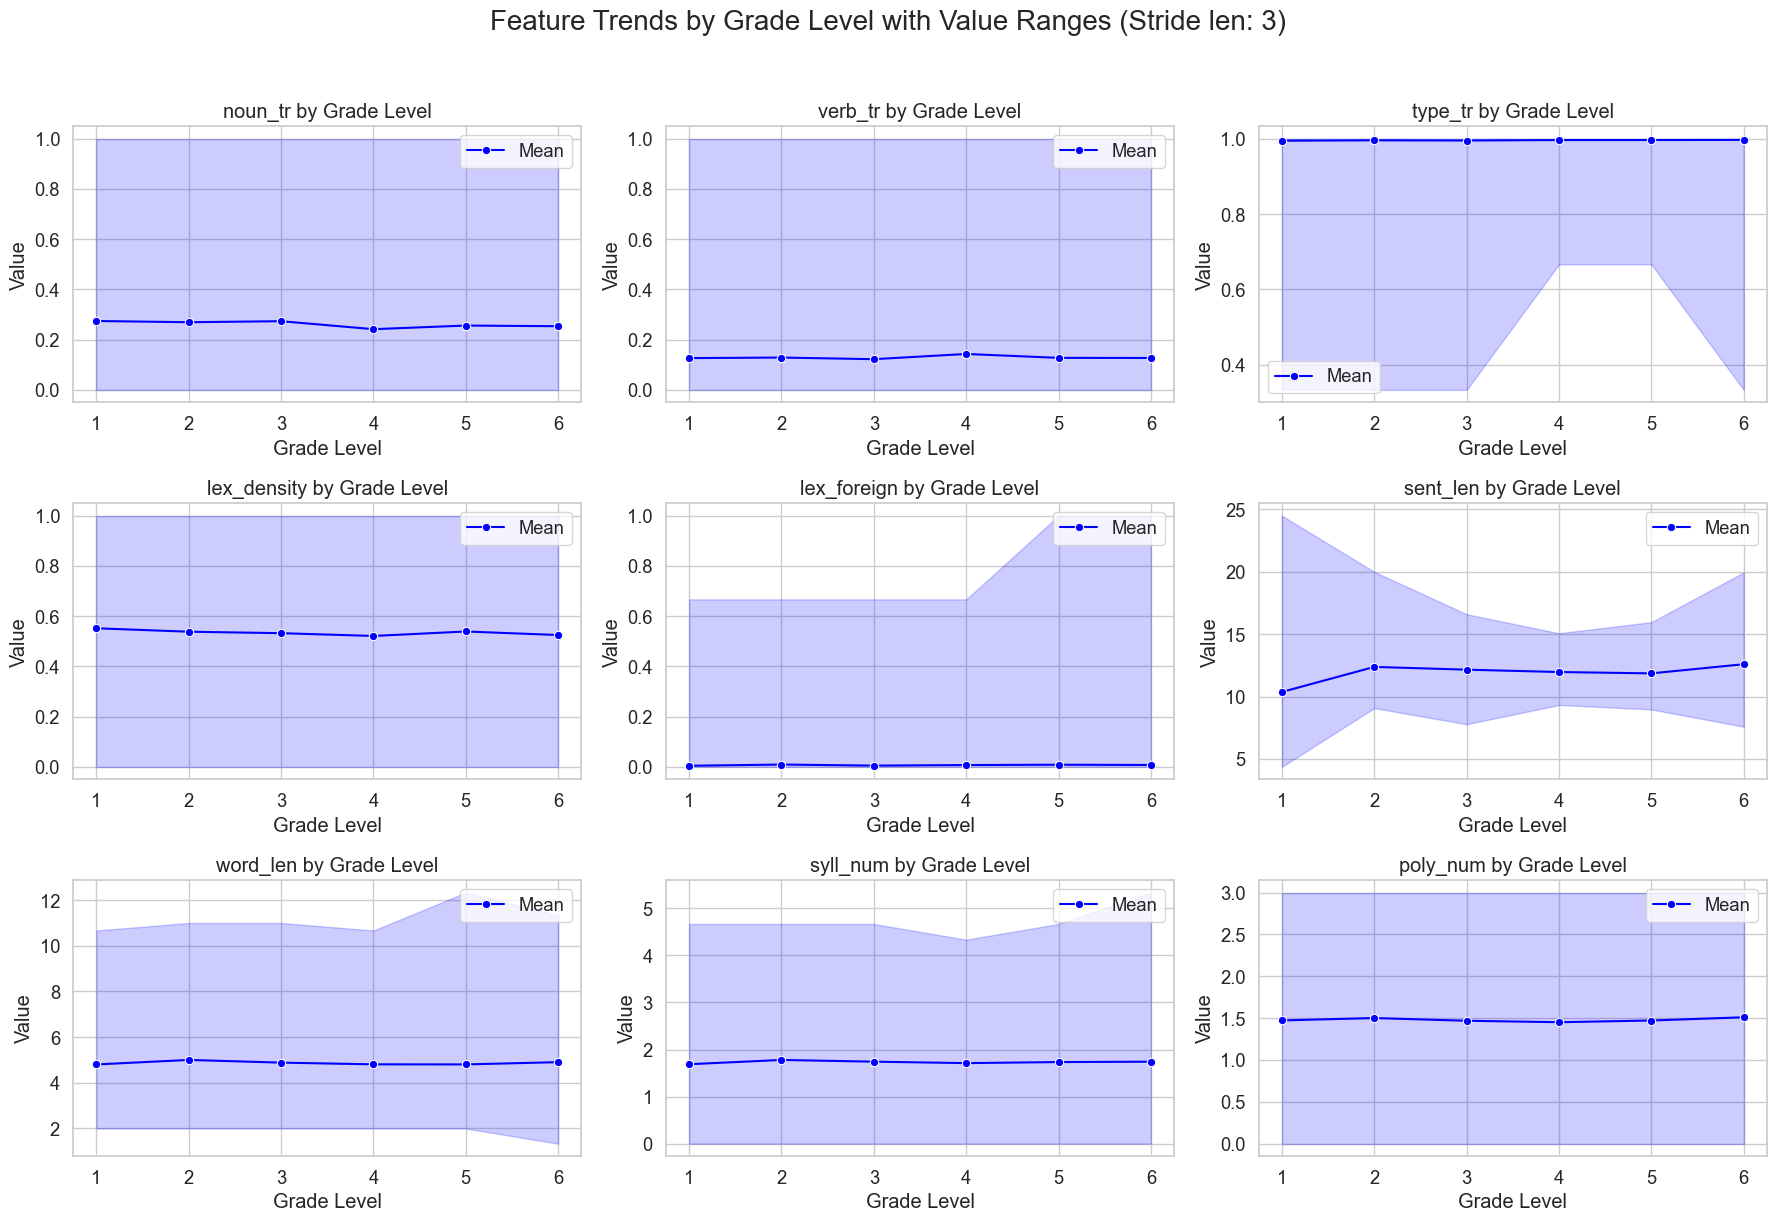

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_mean = database.groupby("grade_level")[feature_cols].mean()
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_min = database.groupby("grade_level")[feature_cols].min()
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_1338/3082457080.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

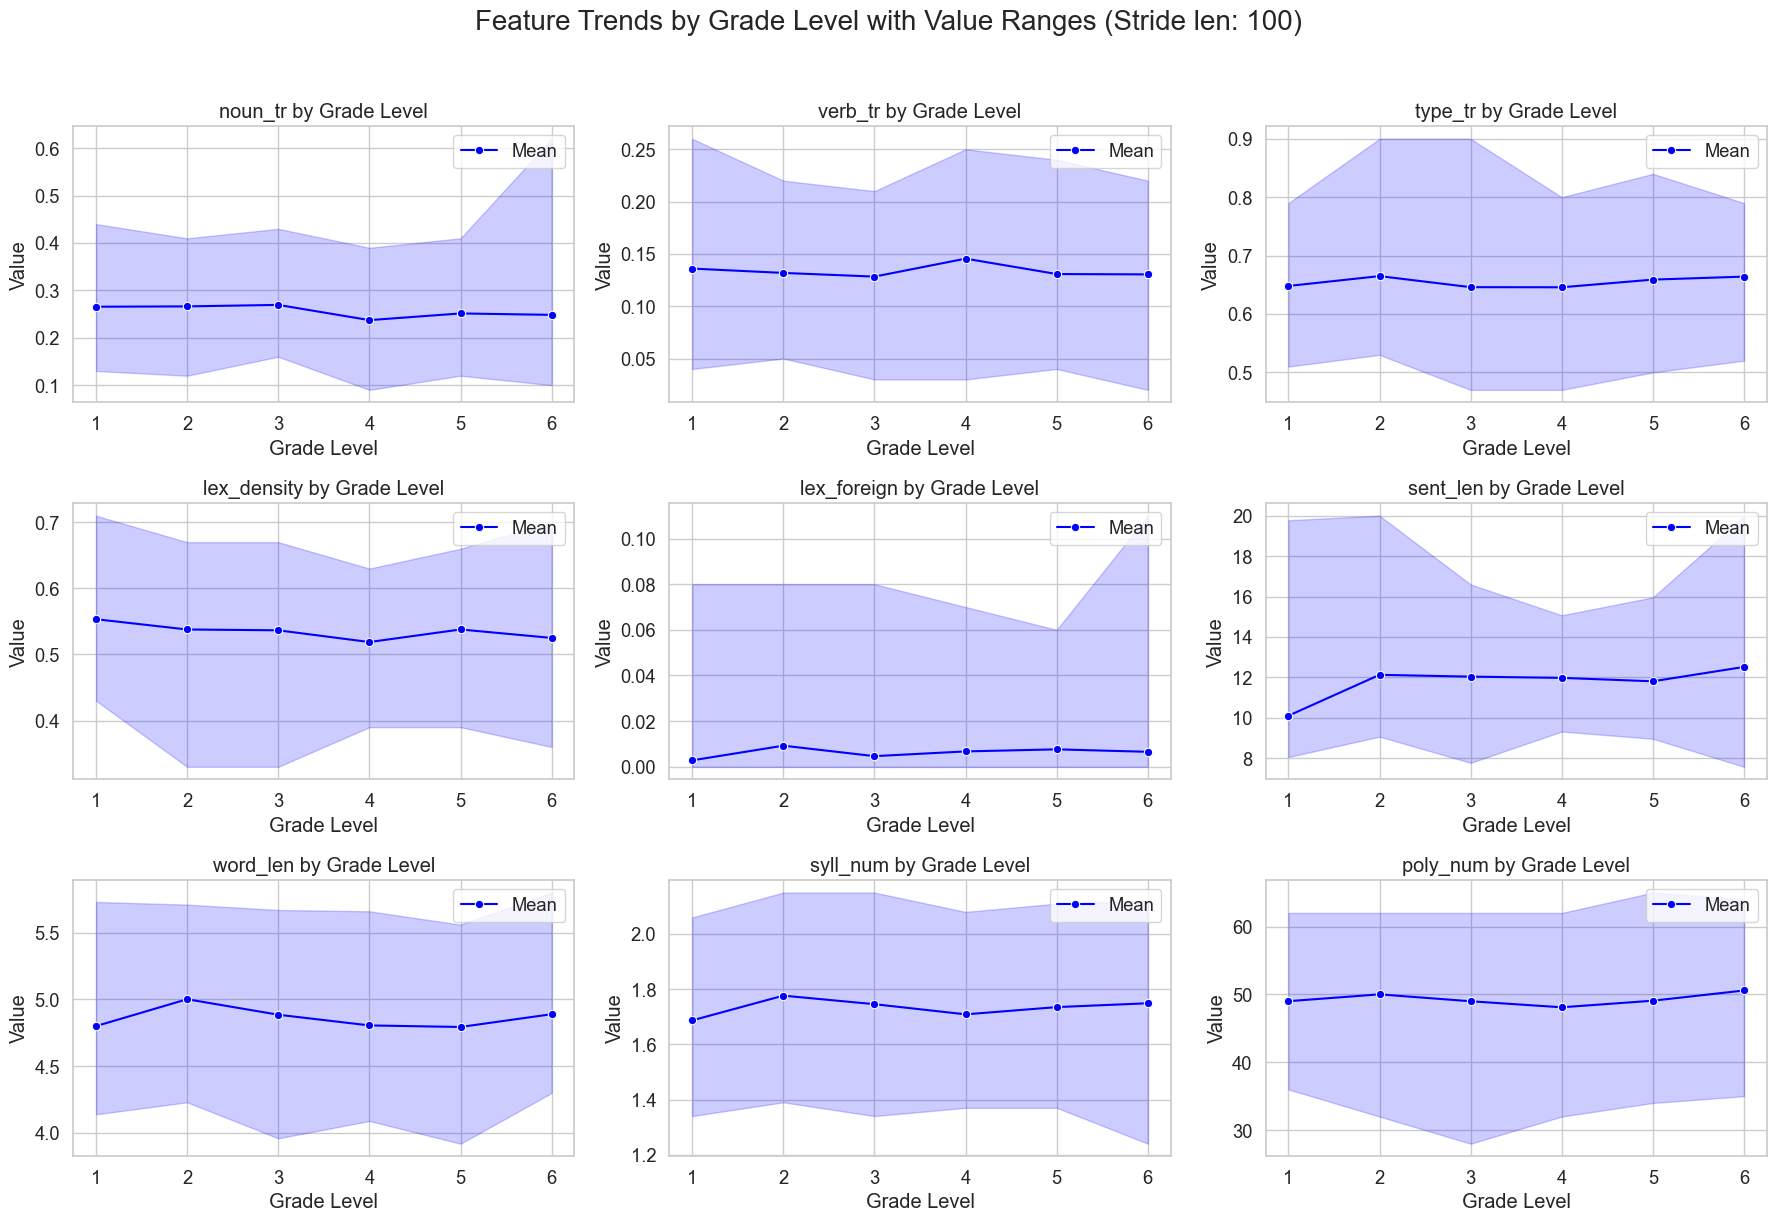

In [14]:

stride = [1, 2, 3, 100]
for s in stride:
    database = df_undersampled[df_undersampled['stride_len'] == s]
    database_name = f"Stride len: {s}"

    feature_cols = [
        "noun_tr", "verb_tr", "type_tr", "lex_density", "lex_foreign",
        "sent_len", "word_len", "syll_num", "poly_num"
    ]

    # Group by grade_level and compute statistics (mean, min, max)
    grouped_mean = database.groupby("grade_level")[feature_cols].mean()
    grouped_min = database.groupby("grade_level")[feature_cols].min()
    grouped_max = database.groupby("grade_level")[feature_cols].max()

    # Plot setup
    sns.set(style="whitegrid", palette="muted", font_scale=1.2)
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
    axes = axes.flatten()

    # Plot each feature with a shaded range (min-max)
    for i, feature in enumerate(feature_cols):
        sns.lineplot(
            x=grouped_mean.index.astype(str),
            y=grouped_mean[feature],
            marker='o',
            ax=axes[i],
            label="Mean",
            color='blue'
        )
        
        # Fill between min and max
        axes[i].fill_between(
            x=grouped_mean.index.astype(str),
            y1=grouped_min[feature],
            y2=grouped_max[feature],
            alpha=0.2,
            color='blue',
            # label="Range (Min-Max)"
        )
        
        axes[i].set_title(f"{feature} by Grade Level")
        axes[i].set_xlabel("Grade Level")
        axes[i].set_ylabel("Value")
        axes[i].legend()

    plt.suptitle(f"Feature Trends by Grade Level with Value Ranges ({database_name})", y=1.02, fontsize=20)
    plt.tight_layout()
    plt.show()